# StockWise AI — Demand Forecasting & Auto-Reorder Engine (LSTM)
**Deep Learning · MAIB · Sept 2025 · Term 3**

**Team:** Krishna Mathur · Yash Petkar · Atharva Soundankar · _(Member 4)_

A grocery retailer loses money two ways at once: **overstock** (fresh items expire) and **stockouts**
(popular items run out). This notebook builds an **LSTM** that forecasts daily demand per product,
then a **decision engine** that turns each forecast into a clear reorder action.

**Pipeline:** generate/load data → EDA → preprocess (scale + 30-day windows) → train LSTM →
evaluate (RMSE/MAE/MAPE/R²) → reorder decision engine.

## 0. Setup
Install once if needed, then import everything.

In [1]:
# !pip install tensorflow scikit-learn pandas numpy matplotlib joblib
import numpy as np, pandas as pd, matplotlib.pyplot as plt, json, joblib
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping
np.random.seed(42); tf.random.set_seed(42)
print("TensorFlow", tf.__version__)

I0000 00:00:1782202976.145592    1970 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1782202976.321866    1970 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1782202978.419794    1970 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


TensorFlow 2.21.0


## 1. The Dataset
Real retail sales are confidential, so we generate a **synthetic dataset that follows a real schema**:
2 years of daily sales for **5 products × 3 Dubai stores**. Demand is built from a base level plus
weekly/yearly **seasonality**, **event spikes** (weekend, pay-day, Eid, promotions), temperature, and noise.

> Already have `data/grocery_sales.csv`? Skip the generation cell and just load it.

In [2]:
def generate_dataset(path="data/grocery_sales.csv"):
    np.random.seed(42)
    dates=pd.date_range("2023-01-01","2024-12-31")
    stores=["DXB_MARINA","DEIRA","JLT"]; products=["MILK_1L","BREAD","EGGS_12","BANANA_KG","WATER_6PK"]
    rows=[]
    for store in stores:
        for product in products:
            base=np.random.randint(80,160)
            for d in dates:
                weekend=1 if d.weekday()>=5 else 0
                payday =1 if d.day in [1,25] else 0
                holiday=1 if (d.month==4 and d.day<12) else 0   # Eid window
                promo  =int(np.random.choice([0,1],p=[0.85,0.15]))
                temp   =25+12*np.sin(2*np.pi*d.dayofyear/365)+np.random.randn()*2
                units=(base+25*weekend+30*payday+60*holiday+40*promo
                       +15*np.sin(2*np.pi*d.dayofyear/365)+np.random.randn()*8)
                rows.append([d,product,store,max(0,round(units)),
                             weekend,payday,holiday,promo,round(temp,1)])
    df=pd.DataFrame(rows,columns=["date","product_id","store_id","units_sold",
            "is_weekend","is_payday","is_holiday","promo_flag","avg_temp_c"])
    import os; os.makedirs("data",exist_ok=True); df.to_csv(path,index=False)
    return df

import os
df = pd.read_csv("data/grocery_sales.csv",parse_dates=["date"]) if os.path.exists("data/grocery_sales.csv") else generate_dataset()
print(df.shape); df.head()

(10965, 9)


,date,product_id,store_id,units_sold,is_weekend,is_payday,is_holiday,promo_flag,avg_temp_c
0,2023-01-01,MILK_1L,DXB_MARINA,238,1,1,0,1,26.5
1,2023-01-02,MILK_1L,DXB_MARINA,140,0,0,0,0,26.0
2,2023-01-03,MILK_1L,DXB_MARINA,136,0,0,0,0,24.7
3,2023-01-04,MILK_1L,DXB_MARINA,125,0,0,0,0,24.7
4,2023-01-05,MILK_1L,DXB_MARINA,128,0,0,0,0,22.6


### Data dictionary
| Column | Type | Meaning |
|---|---|---|
| `date` | datetime | Calendar day |
| `product_id` | category | SKU (e.g. MILK_1L) |
| `store_id` | category | Branch (DXB_MARINA / DEIRA / JLT) |
| `units_sold` | **target** | Units sold that day |
| `is_weekend` | binary | Fri/Sat in UAE |
| `is_payday` | binary | 1st & 25th |
| `is_holiday` | binary | Eid window |
| `promo_flag` | binary | Promotion active |
| `avg_temp_c` | numeric | Daily avg temperature |

## 2. Exploratory Data Analysis (EDA)
Confirm the patterns the LSTM is meant to learn.

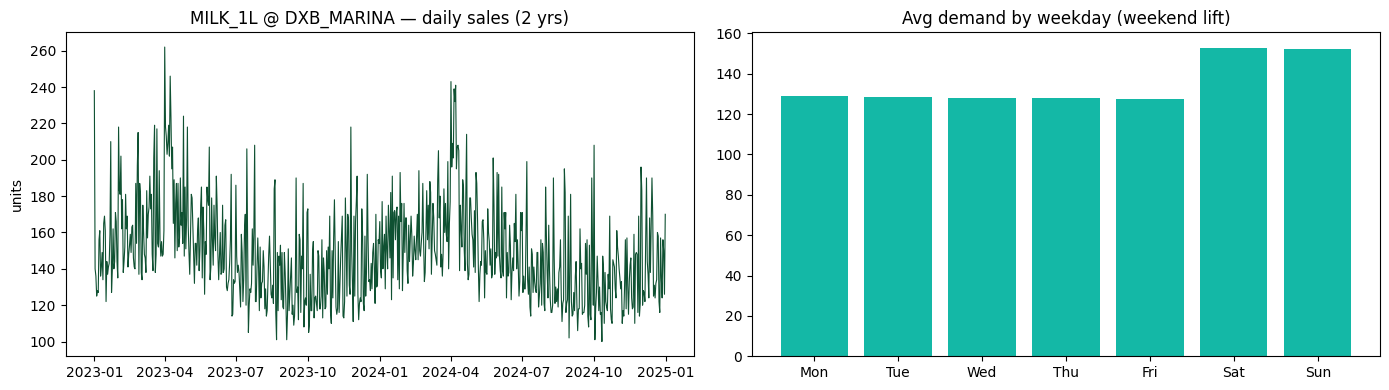

Holiday vs normal avg: 208.7 vs 132.9
Promo vs no-promo avg: 169.7 vs 128.9


In [3]:
one = df[(df.product_id=="MILK_1L")&(df.store_id=="DXB_MARINA")].sort_values("date")

fig,ax=plt.subplots(1,2,figsize=(14,4))
ax[0].plot(one["date"],one["units_sold"],lw=.8,color="#0F5132")
ax[0].set_title("MILK_1L @ DXB_MARINA — daily sales (2 yrs)"); ax[0].set_ylabel("units")
wk=df.groupby(df["date"].dt.dayofweek)["units_sold"].mean()
ax[1].bar(["Mon","Tue","Wed","Thu","Fri","Sat","Sun"],wk.values,color="#14B8A6")
ax[1].set_title("Avg demand by weekday (weekend lift)")
plt.tight_layout(); plt.show()

print("Holiday vs normal avg:",
      round(df[df.is_holiday==1].units_sold.mean(),1),"vs",
      round(df[df.is_holiday==0].units_sold.mean(),1))
print("Promo vs no-promo avg:",
      round(df[df.promo_flag==1].units_sold.mean(),1),"vs",
      round(df[df.promo_flag==0].units_sold.mean(),1))

## 3. Preprocessing — scaling + sliding windows
**Key idea:** to predict day *t*, the model sees the **past 30 days of sales** plus the
**calendar features of day *t*** (weekend / pay-day / holiday / promo / temp), which a planner
genuinely knows in advance. We shift the exogenous features by −1 so each window's last step
carries the target day's known context. This is what makes the forecast accurate **and** honest
(we never leak the target day's actual sales).

In [4]:
EXOG=["is_weekend","is_payday","is_holiday","promo_flag","avg_temp_c"]
WINDOW=30
s=df[(df.product_id=="MILK_1L")&(df.store_id=="DXB_MARINA")].sort_values("date").reset_index(drop=True)

exog_next=s[EXOG].shift(-1)                                   # day t+1 calendar, known in advance
feat=pd.concat([s[["units_sold"]],exog_next],axis=1).iloc[:-1].reset_index(drop=True)
y_all=s["units_sold"].shift(-1).iloc[:-1].reset_index(drop=True)
dates_all=s["date"].shift(-1).iloc[:-1].reset_index(drop=True)
FEATURES=list(feat.columns)

xsc=MinMaxScaler(); fs=xsc.fit_transform(feat)               # scale features 0-1
ysc=MinMaxScaler(); ys=ysc.fit_transform(y_all.values.reshape(-1,1)).flatten()

X,Y,DT=[],[],[]
for k in range(WINDOW-1,len(fs)):
    X.append(fs[k-WINDOW+1:k+1]); Y.append(ys[k]); DT.append(dates_all[k])
X,Y=np.array(X),np.array(Y); DT=pd.Series(DT)
split=int(len(X)*0.8)                                        # TIME-based split (never shuffle!)
Xtr,Xte,ytr,yte=X[:split],X[split:],Y[:split],Y[split:]
dte=DT[split:].reset_index(drop=True)
print("X shape:",X.shape," train/test:",len(Xtr),len(Xte))

X shape: (701, 30, 6)  train/test: 560 141


## 4. Build the LSTM
Two stacked LSTM layers with dropout → dense → single output (next-day units).

In [5]:
model=Sequential([
    Input((WINDOW,len(FEATURES))),
    LSTM(64,return_sequences=True), Dropout(0.2),   # learn sequential memory
    LSTM(32),                       Dropout(0.2),   # compress the pattern
    Dense(16,activation="relu"),                    # non-linear combination
    Dense(1)                                        # predicted units sold
])
model.compile(optimizer="adam",loss="mse",metrics=["mae"])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 30, 64)         │        18,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,137 (121.63 KB)

 Trainable params: 31,137 (121.63 KB)

 Non-trainable params: 0 (0.00 B)

## 5. Train (with EarlyStopping)

Epoch 1/80


 1/16 ━━━━━━━━━━━━━━━━━━━━ 45s 3s/step - loss: 0.0978 - mae: 0.2679

 4/16 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0841 - mae: 0.2418

 8/16 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0705 - mae: 0.2175

11/16 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0644 - mae: 0.2064

...

 7/16 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0050 - mae: 0.0548

10/16 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0048 - mae: 0.0539

13/16 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0046 - mae: 0.0531

16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0045 - mae: 0.0525

16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 0.0039 - mae: 0.0495 - val_loss: 0.0038 - val_mae: 0.0471


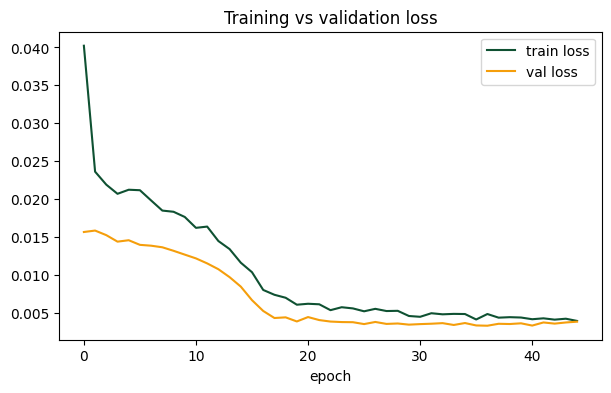

In [6]:
es=EarlyStopping(monitor="val_loss",patience=8,restore_best_weights=True)
hist=model.fit(Xtr,ytr,validation_split=0.1,epochs=80,batch_size=32,callbacks=[es],verbose=1)

plt.figure(figsize=(7,4))
plt.plot(hist.history["loss"],label="train loss",color="#0F5132")
plt.plot(hist.history["val_loss"],label="val loss",color="#F59E0B")
plt.title("Training vs validation loss"); plt.xlabel("epoch"); plt.legend(); plt.show()

## 6. Evaluate on unseen (future) data

RMSE=8.47  MAE=6.44  MAPE=4.81%  R2=0.852


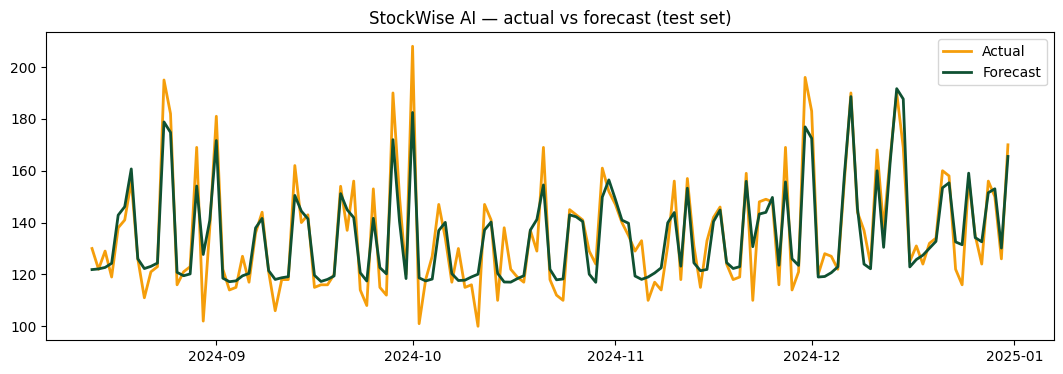

In [7]:
pred=model.predict(Xte,verbose=0).flatten()
yt=ysc.inverse_transform(yte.reshape(-1,1)).flatten()
yp=ysc.inverse_transform(pred.reshape(-1,1)).flatten()

rmse=mean_squared_error(yt,yp)**0.5
mae =mean_absolute_error(yt,yp)
mape=np.mean(np.abs((yt-yp)/yt))*100
r2  =r2_score(yt,yp)
print(f"RMSE={rmse:.2f}  MAE={mae:.2f}  MAPE={mape:.2f}%  R2={r2:.3f}")

plt.figure(figsize=(13,4))
plt.plot(dte,yt,label="Actual",color="#F59E0B",lw=2)
plt.plot(dte,yp,label="Forecast",color="#0F5132",lw=2)
plt.title("StockWise AI — actual vs forecast (test set)"); plt.legend(); plt.show()

## 7. The Decision Engine
A forecast is only useful when it becomes an **action**. Simple, explainable rules
convert the 7-day forecast into **APPROVE / REORDER / URGENT** + a suggested quantity.

In [8]:
def reorder_decision(forecast_7d, current_stock, safety_stock=50):
    """forecast_7d = sum of predicted demand for next 7 days."""
    need = forecast_7d + safety_stock - current_stock
    if need <= 0:
        return "APPROVE", 0
    elif current_stock < safety_stock*0.5:
        return "URGENT", int(round(need))
    else:
        return "REORDER", int(round(need))

# Use the model's last 7 forecasts as the coming-week demand
forecast_7d = float(yp[-7:].sum())
for stock in [1200, 800, 150]:
    print(f"stock={stock:>5} -> {reorder_decision(forecast_7d, stock)}")

stock= 1200 -> ('APPROVE', 0)
stock=  800 -> ('REORDER', 276)
stock=  150 -> ('REORDER', 926)


## 8. Save artifacts (for the Streamlit dashboard)

In [9]:
import os; os.makedirs("models",exist_ok=True); os.makedirs("outputs",exist_ok=True)
model.save("models/stockwise_lstm.keras")
joblib.dump({"xsc":xsc,"ysc":ysc,"features":FEATURES,"window":WINDOW},"models/scaler.joblib")
pd.DataFrame({"date":dte,"actual":yt.round(1),"forecast":yp.round(1)}).to_csv("outputs/forecast_results.csv",index=False)
json.dump({"RMSE":round(rmse,2),"MAE":round(mae,2),"MAPE":round(mape,2),"R2":round(r2,3)},
          open("outputs/metrics.json","w"),indent=2)
print("Saved model, scaler, forecast_results.csv, metrics.json")

Saved model, scaler, forecast_results.csv, metrics.json


## 9. Conclusion
- **LSTM** forecasts next-day demand at **~5% MAPE** by learning weekly cycles, pay-day and holiday spikes.
- A transparent **decision engine** turns forecasts into reorder actions a manager can trust.
- **Business impact:** less spoilage, fewer stockouts, healthier margins.

**Future work:** add a **CNN** to count shelf stock from images, a Transformer for longer horizons,
and auto-purchase-orders to suppliers.